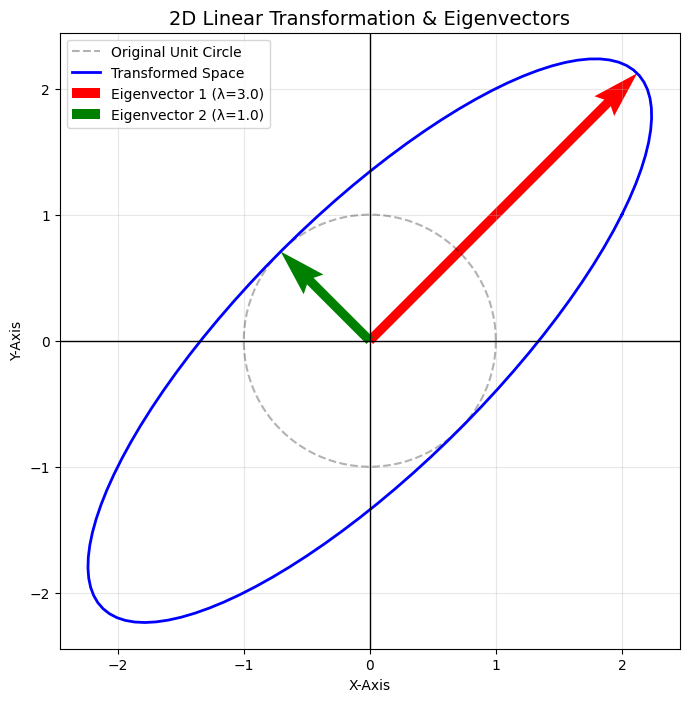

✅ 3D Asset saved: ../../../assets\57_eigen_3d.png


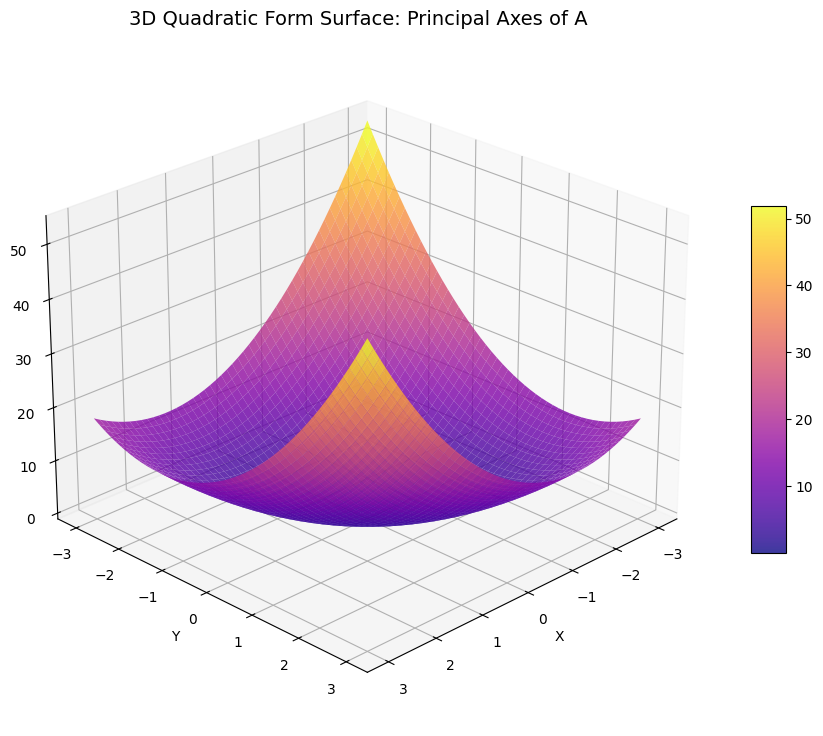

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

def run_eigen_master():
    # --- PROFESSIONAL PATH SETUP (Relative Path) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Define a 2x2 Transformation Matrix
    A = np.array([[2, 1],
                  [1, 2]])
    
    # Calculate Eigenvalues and Eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(A)

    # --- 📸 ASSET 1: 2D TRANSFORMATION (57_eigen_2d.png) ---
    plt.figure(figsize=(8, 8))
    
    # Plot Unit Circle to see the stretch
    theta = np.linspace(0, 2*np.pi, 100)
    circle = np.array([np.cos(theta), np.sin(theta)])
    transformed_circle = A @ circle

    plt.plot(circle[0], circle[1], 'k--', alpha=0.3, label='Original Unit Circle')
    plt.plot(transformed_circle[0], transformed_circle[1], 'b-', lw=2, label='Transformed Space')

    # Plot Eigenvectors
    colors = ['r', 'g']
    for i in range(len(eigenvalues)):
        v = eigenvectors[:, i] * eigenvalues[i]
        plt.quiver(0, 0, v[0], v[1], color=colors[i], angles='xy', scale_units='xy', scale=1, 
                   width=0.015, label=f'Eigenvector {i+1} (λ={eigenvalues[i]:.1f})')

    plt.title("2D Linear Transformation & Eigenvectors", fontsize=14)
    plt.xlabel("X-Axis"); plt.ylabel("Y-Axis")
    plt.grid(alpha=0.3); plt.axhline(0, color='black', lw=1); plt.axvline(0, color='black', lw=1)
    plt.legend(); plt.axis('equal')
    
    save_path_2d = os.path.join(asset_path, '57_eigen_2d.png')
    plt.savefig(save_path_2d, dpi=300)
    plt.show()

    # --- 📸 ASSET 2: 3D QUADRATIC FORM SURFACE (57_eigen_3d.png) ---
    fig = plt.figure(figsize=(12, 9))
    ax3d = fig.add_subplot(111, projection='3d')
    
    x = np.linspace(-3, 3, 50)
    y = np.linspace(-3, 3, 50)
    X, Y = np.meshgrid(x, y)
    
    # Compute Quadratic Form: Z = v^T * A * v
    # For A = [[2,1],[1,2]], Z = 2x^2 + 2xy + 2y^2
    Z = A[0,0]*X**2 + (A[0,1] + A[1,0])*X*Y + A[1,1]*Y**2

    surf = ax3d.plot_surface(X, Y, Z, cmap='plasma', alpha=0.8, edgecolor='none')
    
    ax3d.set_title("3D Quadratic Form Surface: Principal Axes of A", fontsize=14)
    ax3d.set_xlabel("X"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("v^T A v")
    fig.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10)
    
    ax3d.view_init(elev=25, azim=45)

    save_path_3d = os.path.join(asset_path, '57_eigen_3d.png')
    plt.savefig(save_path_3d, dpi=300)
    print(f"✅ 3D Asset saved: {save_path_3d}")
    plt.show()

if __name__ == "__main__":
    run_eigen_master()